# 16 — Plan A: Future Condition Forecasting

This notebook adds the temporal layer to the successful Notebook 15 current-condition artifact.

## Methodological status

The available data do not provide enough qualifying repeated inspections of the same bridge for individually validated longitudinal forecasting.

Therefore this notebook uses the established:

**age-conditioned cohort degradation curve + bootstrap uncertainty**

For a bridge of current age `a` and horizon `h`:

```text
future scenario =
current Plan A prediction
+ [curve(a+h) - curve(a)]
```

Horizons: **+10, +25, +50 years**.

These are population-level future-condition scenarios, not individually validated deterioration predictions.

The frozen current-condition model is not retrained or modified.

## 00 — Project paths

Input:

```text
C:\Datenanalyse\final Project\Output_PlanA-B\
15_Plan_A_Current_Bridge_Condition\
plan_a_current_condition.parquet
```

Output:

```text
C:\Datenanalyse\final Project\Output_PlanA-B\
16_Plan_A_Future_Condition\
```

No legacy directories are searched.

In [1]:
from pathlib import Path
import json
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(r"C:\Datenanalyse\final Project")
OUTPUT_ROOT = PROJECT_ROOT / "Output_PlanA-B"

INPUT_PATH = (
    OUTPUT_ROOT
    / "15_Plan_A_Current_Bridge_Condition"
    / "plan_a_current_condition.parquet"
)

OUTPUT_DIR = OUTPUT_ROOT / "16_Plan_A_Future_Condition"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("INPUT_PATH:", INPUT_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

if not INPUT_PATH.exists():
    raise FileNotFoundError(f"Notebook 15 output not found:\n{INPUT_PATH}")

print("[PASS] configuration")

INPUT_PATH: C:\Datenanalyse\final Project\Output_PlanA-B\15_Plan_A_Current_Bridge_Condition\plan_a_current_condition.parquet
OUTPUT_DIR: C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition
[PASS] configuration


## 01 — Load Notebook 15 output

Expected population: 52,214 existing bridges.

In [2]:
forecast_df = pd.read_parquet(INPUT_PATH)

required = {
    "bridge_id",
    "zustandsnote_observed",
    "zustandsnote_predicted",
    "baujahr",
}

missing = sorted(required - set(forecast_df.columns))
if missing:
    raise KeyError(f"Missing required fields: {missing}")

if len(forecast_df) != 52214:
    raise ValueError(f"Expected 52,214 rows; found {len(forecast_df)}")

if not forecast_df["bridge_id"].is_unique:
    raise ValueError("bridge_id is not unique.")

pred = pd.to_numeric(
    forecast_df["zustandsnote_predicted"],
    errors="coerce"
)

if not np.isfinite(pred).all():
    raise ValueError("Current predictions contain non-finite values.")

print("Shape:", forecast_df.shape)
print("[PASS] Notebook 15 artifact loaded")

Shape: (52214, 17)
[PASS] Notebook 15 artifact loaded


## 02 — Construct bridge age

Age is calculated as:

```text
2026 - baujahr
```

Only ages from 0 through 200 years enter the cohort curve.

Bridges without usable age remain in the final artifact and receive no numerical future scenario.

In [3]:
CURRENT_YEAR = 2026
AGE_MIN = 0
AGE_MAX = 200

forecast_df["baujahr_numeric"] = pd.to_numeric(
    forecast_df["baujahr"],
    errors="coerce"
)

forecast_df["age_years"] = (
    CURRENT_YEAR - forecast_df["baujahr_numeric"]
)

forecast_df.loc[
    ~forecast_df["age_years"].between(AGE_MIN, AGE_MAX),
    "age_years"
] = np.nan

age_data = forecast_df[
    ["bridge_id", "age_years", "zustandsnote_observed"]
].copy()

age_data["observed_zustandsnote"] = pd.to_numeric(
    age_data["zustandsnote_observed"],
    errors="coerce"
)

age_data = age_data[
    ["bridge_id", "age_years", "observed_zustandsnote"]
].dropna()

if len(age_data) < 100:
    raise RuntimeError("Insufficient age/condition observations.")

print("Usable age/condition rows:", len(age_data))
print("Age range:", age_data["age_years"].min(), "to", age_data["age_years"].max())
print("[PASS] age data prepared")

Usable age/condition rows: 52213
Age range: 0.0 to 125.0
[PASS] age data prepared


## 03 — Build age-conditioned cohort curve

Established bins:

`0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 150, 200`

Only cohorts with at least 50 observations are retained.

In [4]:
AGE_BINS = np.array(
    [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 120, 150, 200],
    dtype=float
)

age_data["age_bin"] = pd.cut(
    age_data["age_years"],
    bins=AGE_BINS,
    include_lowest=True,
    right=True,
)

cohort_curve = (
    age_data
    .groupby("age_bin", observed=False)["observed_zustandsnote"]
    .agg(
        n="count",
        median="median",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        mean="mean",
    )
    .reset_index()
)

cohort_curve["age_mid"] = cohort_curve["age_bin"].apply(
    lambda x: float(x.mid) if pd.notna(x) else np.nan
)

cohort_curve = cohort_curve[
    cohort_curve["n"] >= 50
].copy()

if len(cohort_curve) < 5:
    raise RuntimeError(
        f"Fewer than 5 sufficiently supported cohorts: {len(cohort_curve)}"
    )

display(cohort_curve)
print("[PASS] cohort curve constructed")

,age_bin,n,median,q25,q75,mean,age_mid
0,"(-0.001, 5.0]",1081,1.8,1.2,2.0,1.670213,2.4995
1,"(5.0, 10.0]",2185,1.9,1.4,2.2,1.796064,7.5000
2,"(10.0, 20.0]",5718,2.0,1.8,2.3,1.947307,15.0000
3,"(20.0, 30.0]",9203,2.2,1.9,2.4,2.111790,25.0000
4,"(30.0, 40.0]",6568,2.2,2.0,2.4,2.190606,35.0000
5,"(40.0, 50.0]",9337,2.3,2.0,2.5,2.300910,45.0000
6,"(50.0, 60.0]",10884,2.4,2.1,2.7,2.371031,55.0000
7,"(60.0, 70.0]",4601,2.4,2.1,2.7,2.379917,65.0000
8,"(70.0, 80.0]",782,2.4,2.2,2.8,2.453069,75.0000
9,"(80.0, 90.0]",1290,2.3,2.0,2.7,2.337907,85.0000


[PASS] cohort curve constructed


## 04 — Robust age-condition diagnostics

These diagnose an age-condition association. They do not prove an individual deterioration trajectory.

In [5]:
x = cohort_curve["age_mid"].to_numpy(dtype=float)
y = cohort_curve["median"].to_numpy(dtype=float)

pairwise_slopes = []
for i in range(len(x)):
    for j in range(i + 1, len(x)):
        dx = x[j] - x[i]
        if dx > 0:
            pairwise_slopes.append((y[j] - y[i]) / dx)

ROBUST_SLOPE = float(np.median(pairwise_slopes))
OLS_SLOPE, OLS_INTERCEPT = np.polyfit(x, y, 1)
ols_pred = OLS_INTERCEPT + OLS_SLOPE * x

ss_res = np.sum((y - ols_pred) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
OLS_R2 = float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

MONOTONICITY_RATE = float(np.mean(np.diff(y) >= -0.10))

print("Robust slope:", round(ROBUST_SLOPE, 6), "ZN/year")
print("OLS slope:", round(float(OLS_SLOPE), 6), "ZN/year")
print("Descriptive OLS R²:", round(OLS_R2, 4))
print("Monotonicity rate:", round(MONOTONICITY_RATE, 4))

Robust slope: 0.005 ZN/year
OLS slope: 0.005146 ZN/year
Descriptive OLS R²: 0.731
Monotonicity rate: 0.9091


## 05 — Held-out population validation

A bridge-level group split is used so the age-condition curve is constructed from training bridges and evaluated on held-out bridges.

This validates population age-condition association, not individual future forecasting.

In [6]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(age_data, groups=age_data["bridge_id"])
)

train_age = age_data.iloc[train_idx].copy()
test_age = age_data.iloc[test_idx].copy()

train_age["age_bin"] = pd.cut(
    train_age["age_years"],
    bins=AGE_BINS,
    include_lowest=True,
    right=True,
)

train_curve = (
    train_age
    .groupby("age_bin", observed=False)["observed_zustandsnote"]
    .median()
    .reset_index(name="median")
)

train_curve["age_mid"] = train_curve["age_bin"].apply(
    lambda x: float(x.mid) if pd.notna(x) else np.nan
)

train_counts = (
    train_age
    .groupby("age_bin", observed=False)["observed_zustandsnote"]
    .count()
    .reset_index(name="n")
)

train_curve = (
    train_curve
    .merge(train_counts, on="age_bin")
    .dropna()
)

train_curve = train_curve[train_curve["n"] >= 30]

if len(train_curve) < 5:
    raise RuntimeError("Held-out training curve has fewer than 5 supported cohorts.")

train_x = train_curve["age_mid"].to_numpy(dtype=float)
train_y = train_curve["median"].to_numpy(dtype=float)

test_age["cohort_pred"] = np.interp(
    np.clip(test_age["age_years"], train_x.min(), train_x.max()),
    train_x,
    train_y,
)

test_actual = test_age["observed_zustandsnote"].to_numpy(dtype=float)
test_pred = test_age["cohort_pred"].to_numpy(dtype=float)

heldout_metrics = {
    "n_train": int(len(train_age)),
    "n_test": int(len(test_age)),
    "train_supported_cohorts": int(len(train_curve)),
    "MAE": float(mean_absolute_error(test_actual, test_pred)),
    "RMSE": float(np.sqrt(mean_squared_error(test_actual, test_pred))),
    "R2": float(r2_score(test_actual, test_pred)),
}

print("Held-out population validation:")
print(heldout_metrics)
print("[PASS] held-out population diagnostic")

Held-out population validation:
{'n_train': 41770, 'n_test': 10443, 'train_supported_cohorts': 12, 'MAE': 0.3207526856239014, 'RMSE': 0.41960953084422853, 'R2': 0.15150346062932207}
[PASS] held-out population diagnostic


## 06 — Bootstrap uncertainty

Established configuration:

- 300 bootstrap replicates
- seed 42
- age grid 0–150 years
- minimum 30 observations per bootstrap cohort

The band is an empirical uncertainty band, not a formally calibrated prediction interval.

In [7]:
rng = np.random.default_rng(42)

BOOTSTRAP_REPS = 300
AGE_GRID = np.arange(0, 151, 1, dtype=float)

bootstrap_source = age_data.copy()
n_rows = len(bootstrap_source)

bootstrap_curves = np.full(
    (BOOTSTRAP_REPS, len(AGE_GRID)),
    np.nan,
    dtype=float
)

for b in range(BOOTSTRAP_REPS):

    sample_idx = rng.integers(
        0,
        n_rows,
        size=n_rows
    )

    sample = bootstrap_source.iloc[sample_idx].copy()

    sample["age_bin"] = pd.cut(
        sample["age_years"],
        bins=AGE_BINS,
        include_lowest=True,
        right=True,
    )

    c = (
        sample
        .groupby(
            "age_bin",
            observed=False
        )["observed_zustandsnote"]
        .median()
        .reset_index(name="median")
    )

    c["age_mid"] = c["age_bin"].apply(
        lambda z: float(z.mid) if pd.notna(z) else np.nan
    )

    counts = (
        sample
        .groupby(
            "age_bin",
            observed=False
        )["observed_zustandsnote"]
        .count()
        .reset_index(name="n")
    )

    c = (
        c.merge(counts, on="age_bin")
        .dropna()
    )

    c = c[c["n"] >= 30]

    if len(c) >= 5:
        cx = c["age_mid"].to_numpy(dtype=float)
        cy = c["median"].to_numpy(dtype=float)

        bootstrap_curves[b] = np.interp(
            np.clip(AGE_GRID, cx.min(), cx.max()),
            cx,
            cy,
        )

valid_boot = np.isfinite(bootstrap_curves).all(axis=1)
bootstrap_curves = bootstrap_curves[valid_boot]

if len(bootstrap_curves) < 100:
    raise RuntimeError(
        f"Only {len(bootstrap_curves)} valid bootstrap replicates."
    )

curve_p025 = np.quantile(bootstrap_curves, 0.025, axis=0)
curve_p50 = np.quantile(bootstrap_curves, 0.50, axis=0)
curve_p975 = np.quantile(bootstrap_curves, 0.975, axis=0)

print("Valid bootstrap replicates:", len(bootstrap_curves))
print("[PASS] bootstrap uncertainty ready")

Valid bootstrap replicates: 300
[PASS] bootstrap uncertainty ready


## 07 — Visualize the cohort curve

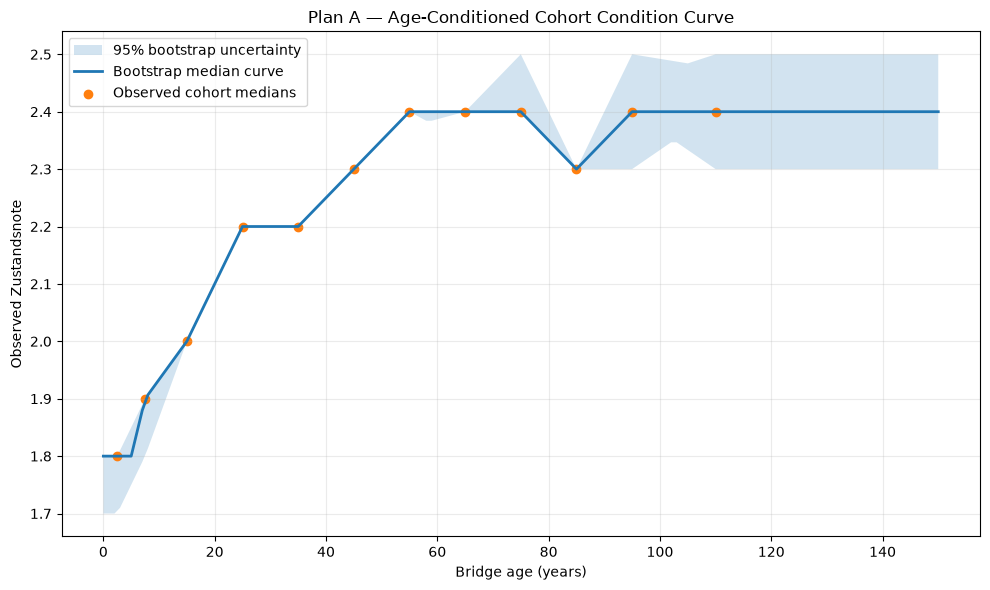

In [8]:
plt.figure(figsize=(10, 6))
plt.fill_between(
    AGE_GRID,
    curve_p025,
    curve_p975,
    alpha=0.20,
    label="95% bootstrap uncertainty"
)
plt.plot(
    AGE_GRID,
    curve_p50,
    linewidth=2,
    label="Bootstrap median curve"
)
plt.scatter(
    cohort_curve["age_mid"],
    cohort_curve["median"],
    label="Observed cohort medians"
)
plt.xlabel("Bridge age (years)")
plt.ylabel("Observed Zustandsnote")
plt.title("Plan A — Age-Conditioned Cohort Condition Curve")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## 08 — Generate +10 / +25 / +50 year scenarios

The bridge-specific current prediction from Notebook 15 is preserved.

Only the population-level age effect is transferred.

In [9]:
curve_lookup = pd.DataFrame({
    "age_years": AGE_GRID,
    "median": curve_p50,
    "lower_95": curve_p025,
    "upper_95": curve_p975,
})

def curve_value(age, column):
    return np.interp(
        np.clip(
            np.asarray(age, dtype=float),
            AGE_GRID.min(),
            AGE_GRID.max()
        ),
        AGE_GRID,
        curve_lookup[column].to_numpy(dtype=float),
    )

scenario = forecast_df[
    [
        "bridge_id",
        "zustandsnote_predicted",
        "age_years",
        "baujahr_numeric",
    ]
].copy()

scenario = scenario.rename(
    columns={"zustandsnote_predicted": "predicted_zustandsnote_t0"}
)

for h in [10, 25, 50]:

    current_center = curve_value(
        scenario["age_years"], "median"
    )
    future_center = curve_value(
        scenario["age_years"] + h, "median"
    )

    delta = future_center - current_center

    scenario[f"zustandsnote_tplus_{h}y"] = np.where(
        scenario["age_years"].notna(),
        np.clip(
            scenario["predicted_zustandsnote_t0"] + delta,
            1.0,
            4.0,
        ),
        np.nan,
    )

    current_upper = curve_value(
        scenario["age_years"], "upper_95"
    )
    current_lower = curve_value(
        scenario["age_years"], "lower_95"
    )
    future_upper = curve_value(
        scenario["age_years"] + h, "upper_95"
    )
    future_lower = curve_value(
        scenario["age_years"] + h, "lower_95"
    )

    lower_delta = future_lower - current_upper
    upper_delta = future_upper - current_lower

    scenario[f"zustandsnote_tplus_{h}y_lower"] = np.where(
        scenario["age_years"].notna(),
        np.clip(
            scenario["predicted_zustandsnote_t0"] + lower_delta,
            1.0,
            4.0,
        ),
        np.nan,
    )

    scenario[f"zustandsnote_tplus_{h}y_upper"] = np.where(
        scenario["age_years"].notna(),
        np.clip(
            scenario["predicted_zustandsnote_t0"] + upper_delta,
            1.0,
            4.0,
        ),
        np.nan,
    )

scenario["zustandsnote_t0"] = scenario["predicted_zustandsnote_t0"]

scenario["forecast_mode"] = "COHORT_AGE_CONDITIONED_BOOTSTRAP"

scenario["forecast_status"] = (
    "POPULATION_SCENARIO_NOT_VALIDATED_INDIVIDUAL_LONGITUDINAL_FORECAST"
)

display(scenario.head())
print("[PASS] future scenarios generated")

,bridge_id,predicted_zustandsnote_t0,age_years,baujahr_numeric,zustandsnote_tplus_10y,zustandsnote_tplus_10y_lower,zustandsnote_tplus_10y_upper,zustandsnote_tplus_25y,zustandsnote_tplus_25y_lower,zustandsnote_tplus_25y_upper,zustandsnote_tplus_50y,zustandsnote_tplus_50y_lower,zustandsnote_tplus_50y_upper,zustandsnote_t0,forecast_mode,forecast_status
0,1019500._0,2.153072,53.0,1973,2.173072,2.167822,2.173072,2.143072,2.143072,2.213072,2.173072,2.119739,2.260405,2.153072,COHORT_AGE_CONDITIONED_BOOTSTRAP,POPULATION_SCENARIO_NOT_VALIDATED_INDIVIDUAL_L...
1,1119503._0,2.247010,65.0,1961,2.247010,2.247010,2.347010,2.197010,2.147010,2.247010,2.247010,2.147010,2.347010,2.247010,COHORT_AGE_CONDITIONED_BOOTSTRAP,POPULATION_SCENARIO_NOT_VALIDATED_INDIVIDUAL_L...
2,1119505._0,2.153068,64.0,1962,2.153068,2.153068,2.245693,2.093068,2.053068,2.135693,2.153068,2.053068,2.255693,2.153068,COHORT_AGE_CONDITIONED_BOOTSTRAP,POPULATION_SCENARIO_NOT_VALIDATED_INDIVIDUAL_L...
3,1119512._0,2.247930,45.0,1981,2.347930,2.347930,2.347930,2.347930,2.347930,2.397930,2.347930,2.247930,2.447930,2.247930,COHORT_AGE_CONDITIONED_BOOTSTRAP,POPULATION_SCENARIO_NOT_VALIDATED_INDIVIDUAL_L...
4,1119514._0,2.247010,40.0,1986,2.347010,2.347010,2.347010,2.397010,2.397010,2.397010,2.347010,2.297010,2.397010,2.247010,COHORT_AGE_CONDITIONED_BOOTSTRAP,POPULATION_SCENARIO_NOT_VALIDATED_INDIVIDUAL_L...


[PASS] future scenarios generated


## 09 — Numerical validation

In [10]:
scenario_checks = []

for h in [10, 25, 50]:

    center = scenario[f"zustandsnote_tplus_{h}y"]
    lower = scenario[f"zustandsnote_tplus_{h}y_lower"]
    upper = scenario[f"zustandsnote_tplus_{h}y_upper"]

    valid = center.dropna()
    valid_lower = lower.loc[valid.index]
    valid_upper = upper.loc[valid.index]

    scenario_checks.append({
        "horizon": h,
        "n": int(len(valid)),
        "finite": bool(np.isfinite(valid).all()),
        "range_1_4": bool(valid.between(1, 4).all()),
        "lower_le_center": bool((valid_lower <= valid).all()),
        "center_le_upper": bool((valid <= valid_upper).all()),
        "mean": float(valid.mean()),
        "median": float(valid.median()),
    })

scenario_checks = pd.DataFrame(scenario_checks)
display(scenario_checks)

if not scenario_checks[
    ["finite", "range_1_4", "lower_le_center", "center_le_upper"]
].all().all():
    raise ValueError("Future scenario numerical validation failed.")

print("[PASS] future scenario numerical check")

,horizon,n,finite,range_1_4,lower_le_center,center_le_upper,mean,median
0,10,52213,True,True,True,True,2.315512,2.323117
1,25,52213,True,True,True,True,2.358685,2.367982
2,50,52213,True,True,True,True,2.396242,2.383100


[PASS] future scenario numerical check


## 10 — Deterioration-direction diagnostic

In [11]:
direction_rows = []

for h in [10, 25, 50]:

    base = scenario["zustandsnote_t0"]
    future = scenario[f"zustandsnote_tplus_{h}y"]

    valid = base.notna() & future.notna()
    violations = future.loc[valid] < base.loc[valid]

    direction_rows.append({
        "horizon": h,
        "n": int(valid.sum()),
        "violations": int(violations.sum()),
        "violation_rate": (
            float(violations.mean()) if valid.sum() else np.nan
        ),
    })

direction_check = pd.DataFrame(direction_rows)
display(direction_check)

if (direction_check["violations"] > 0).any():
    print(
        "DIRECTION CHECK: CONDITIONAL — "
        "some bridges improve under the cohort scenario."
    )
else:
    print("DIRECTION CHECK: PASS")

,horizon,n,violations,violation_rate
0,10,52213,2494,0.047766
1,25,52213,12879,0.246663
2,50,52213,0,0.000000


DIRECTION CHECK: CONDITIONAL — some bridges improve under the cohort scenario.


## 11 — Age-support and extrapolation risk

In [12]:
MAX_SUPPORTED_AGE = float(AGE_GRID.max())

for h in [10, 25, 50]:
    scenario[f"age_plus_{h}"] = (
        scenario["age_years"] + h
    )
    scenario[f"extrapolation_risk_{h}y"] = (
        scenario[f"age_plus_{h}"] > MAX_SUPPORTED_AGE
    )

scenario["age_support_status"] = np.select(
    [
        scenario["extrapolation_risk_50y"],
        scenario["extrapolation_risk_25y"],
        scenario["extrapolation_risk_10y"],
    ],
    [
        "EXTRAPOLATION_RISK_50Y",
        "EXTRAPOLATION_RISK_25Y",
        "EXTRAPOLATION_RISK_10Y",
    ],
    default="WITHIN_CURVE_SUPPORT",
)

risk_share_50y = float(
    scenario["extrapolation_risk_50y"].mean()
)

print("Curve maximum supported age:", MAX_SUPPORTED_AGE)
print("Share with +50y beyond curve grid:", round(risk_share_50y, 4))

if risk_share_50y > 0:
    print("EXTRAPOLATION CHECK: CONDITIONAL")
else:
    print("EXTRAPOLATION CHECK: PASS")

Curve maximum supported age: 150.0
Share with +50y beyond curve grid: 0.0033
EXTRAPOLATION CHECK: CONDITIONAL


## 12 — Final temporal status

```text
CONDITIONAL
```

The future values are population-level cohort scenarios.

They must not be presented as individually validated longitudinal forecasts.

A future PASS for individual forecasting would require repeated inspection histories and time-aware backtesting.

In [13]:
FINAL_DECISION = "CONDITIONAL"

FINAL_REASON = (
    "The age-conditioned cohort curve provides population-level "
    "future-condition scenarios with bootstrap uncertainty, but "
    "available evidence does not provide sufficient repeated "
    "observations for individually validated longitudinal forecasting."
)

print("PLAN A FUTURE CONDITION")
print("DECISION:", FINAL_DECISION)
print("REASON:", FINAL_REASON)
print("FROZEN CURRENT-CONDITION MODEL: UNCHANGED")

PLAN A FUTURE CONDITION
DECISION: CONDITIONAL
REASON: The age-conditioned cohort curve provides population-level future-condition scenarios with bootstrap uncertainty, but available evidence does not provide sufficient repeated observations for individually validated longitudinal forecasting.
FROZEN CURRENT-CONDITION MODEL: UNCHANGED


## 13 — Export artifacts

```text
Output_PlanA-B/
└── 16_Plan_A_Future_Condition/
    ├── plan_a_future_condition.parquet
    ├── plan_a_future_condition.csv
    ├── plan_a_age_conditioned_degradation_curve.csv
    ├── 16_plan_a_future_condition_summary.csv
    └── 16_plan_a_future_condition_manifest.json
```

In [14]:
FORECAST_PARQUET = OUTPUT_DIR / "plan_a_future_condition.parquet"
FORECAST_CSV = OUTPUT_DIR / "plan_a_future_condition.csv"
CURVE_CSV = OUTPUT_DIR / "plan_a_age_conditioned_degradation_curve.csv"
SUMMARY_CSV = OUTPUT_DIR / "16_plan_a_future_condition_summary.csv"
MANIFEST_JSON = OUTPUT_DIR / "16_plan_a_future_condition_manifest.json"

scenario.to_parquet(FORECAST_PARQUET, index=False)
scenario.to_csv(FORECAST_CSV, index=False)

curve_export = pd.DataFrame({
    "age_years": AGE_GRID,
    "median": curve_p50,
    "lower_95_bootstrap": curve_p025,
    "upper_95_bootstrap": curve_p975,
})
curve_export.to_csv(CURVE_CSV, index=False)

summary = pd.DataFrame([
    {"metric": "bridge_count", "value": int(len(scenario))},
    {"metric": "bridges_with_usable_age", "value": int(scenario["age_years"].notna().sum())},
    {"metric": "supported_cohort_count", "value": int(len(cohort_curve))},
    {"metric": "valid_bootstrap_replicates", "value": int(len(bootstrap_curves))},
    {"metric": "heldout_population_mae", "value": heldout_metrics["MAE"]},
    {"metric": "heldout_population_rmse", "value": heldout_metrics["RMSE"]},
    {"metric": "heldout_population_r2", "value": heldout_metrics["R2"]},
    {"metric": "robust_slope_zn_per_year", "value": ROBUST_SLOPE},
    {"metric": "risk_share_50y", "value": risk_share_50y},
])
summary.to_csv(SUMMARY_CSV, index=False)

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = {
    "notebook": "16_Plan_A_Future_Condition",
    "decision": FINAL_DECISION,
    "reason": FINAL_REASON,
    "input": str(INPUT_PATH),
    "input_sha256": sha256_file(INPUT_PATH),
    "bridge_count": int(len(scenario)),
    "current_year": CURRENT_YEAR,
    "age_bins": AGE_BINS.tolist(),
    "age_grid_min": int(AGE_GRID.min()),
    "age_grid_max": int(AGE_GRID.max()),
    "bootstrap_replicates_requested": BOOTSTRAP_REPS,
    "bootstrap_replicates_valid": int(len(bootstrap_curves)),
    "bootstrap_random_seed": 42,
    "horizons_years": [0, 10, 25, 50],
    "scenario_type": "COHORT_AGE_CONDITIONED_BOOTSTRAP",
    "individual_longitudinal_validation": False,
    "frozen_current_model_changed": False,
    "diagnostics": {
        "robust_slope_zn_per_year": ROBUST_SLOPE,
        "ols_slope_zn_per_year": float(OLS_SLOPE),
        "descriptive_ols_r2": OLS_R2,
        "monotonicity_rate": MONOTONICITY_RATE,
        "heldout_population_validation": heldout_metrics,
        "risk_share_50y": risk_share_50y,
    },
    "outputs": {
        "forecast_parquet": str(FORECAST_PARQUET),
        "forecast_csv": str(FORECAST_CSV),
        "curve_csv": str(CURVE_CSV),
        "summary_csv": str(SUMMARY_CSV),
    },
}

MANIFEST_JSON.write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("[PASS] Forecast Parquet:", FORECAST_PARQUET)
print("[PASS] Forecast CSV:", FORECAST_CSV)
print("[PASS] Curve CSV:", CURVE_CSV)
print("[PASS] Summary CSV:", SUMMARY_CSV)
print("[PASS] Manifest JSON:", MANIFEST_JSON)

[PASS] Forecast Parquet: C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition\plan_a_future_condition.parquet
[PASS] Forecast CSV: C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition\plan_a_future_condition.csv
[PASS] Curve CSV: C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition\plan_a_age_conditioned_degradation_curve.csv
[PASS] Summary CSV: C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition\16_plan_a_future_condition_summary.csv
[PASS] Manifest JSON: C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition\16_plan_a_future_condition_manifest.json


## 14 — Final Notebook 16 gate

Required:

- 52,214 bridge rows;
- unique bridge IDs;
- current prediction retained;
- +10/+25/+50 scenario fields;
- finite future values wherever age is available;
- lower ≤ center ≤ upper;
- extrapolation flags;
- all output artifacts;
- frozen current-condition model unchanged.

In [15]:
required_future_cols = [
    "zustandsnote_t0",
    "zustandsnote_tplus_10y",
    "zustandsnote_tplus_25y",
    "zustandsnote_tplus_50y",
    "zustandsnote_tplus_10y_lower",
    "zustandsnote_tplus_10y_upper",
    "zustandsnote_tplus_25y_lower",
    "zustandsnote_tplus_25y_upper",
    "zustandsnote_tplus_50y_lower",
    "zustandsnote_tplus_50y_upper",
    "extrapolation_risk_10y",
    "extrapolation_risk_25y",
    "extrapolation_risk_50y",
]

final_checks = {
    "bridge_count_52214": len(scenario) == 52214,
    "unique_bridge_id": scenario["bridge_id"].nunique() == 52214,
    "future_columns_present": all(
        c in scenario.columns for c in required_future_cols
    ),
    "parquet_exists": FORECAST_PARQUET.exists(),
    "csv_exists": FORECAST_CSV.exists(),
    "curve_exists": CURVE_CSV.exists(),
    "summary_exists": SUMMARY_CSV.exists(),
    "manifest_exists": MANIFEST_JSON.exists(),
}

for h in [10, 25, 50]:
    s = scenario[f"zustandsnote_tplus_{h}y"].dropna()
    final_checks[f"horizon_{h}_finite"] = bool(np.isfinite(s).all())
    final_checks[f"horizon_{h}_range_1_4"] = bool(s.between(1, 4).all())

print("FINAL NOTEBOOK 16 GATE")
for name, passed in final_checks.items():
    print(f"[{'PASS' if passed else 'FAIL'}] {name}")

if not all(final_checks.values()):
    raise RuntimeError("Notebook 16 final gate failed.")

print()
print("16 STATUS: COMPLETE")
print("Next notebook input:")
print(FORECAST_PARQUET)

FINAL NOTEBOOK 16 GATE
[PASS] bridge_count_52214
[PASS] unique_bridge_id
[PASS] future_columns_present
[PASS] parquet_exists
[PASS] csv_exists
[PASS] curve_exists
[PASS] summary_exists
[PASS] manifest_exists
[PASS] horizon_10_finite
[PASS] horizon_10_range_1_4
[PASS] horizon_25_finite
[PASS] horizon_25_range_1_4
[PASS] horizon_50_finite
[PASS] horizon_50_range_1_4

16 STATUS: COMPLETE
Next notebook input:
C:\Datenanalyse\final Project\Output_PlanA-B\16_Plan_A_Future_Condition\plan_a_future_condition.parquet
